In [1]:
import pandas as pd

num_rows = int(input("Enter the number of rows: "))
num_cols = int(input("Enter the number of columns: "))

data = []
for i in range(num_rows):
    row = []
    print(f"Enter data for row {i+1}:")
    for j in range(num_cols):
                value = float(input(f"  Enter numeric value for column {j+1}: "))
                row.append(value)


    data.append(row)


column_names = [f"col_{k+1}" for k in range(num_cols)]

df_dynamic = pd.DataFrame(data, columns=column_names)


Enter data for row 1:
Enter data for row 2:
Enter data for row 3:
Enter data for row 4:


In [2]:
df = df_dynamic

In [3]:
df

,col_1,col_2,col_3,col_4
0,2.0,70.0,12.0,45.0
1,4.0,80.0,15.0,60.0
2,6.0,85.0,18.0,75.0
3,8.0,90.0,20.0,90.0


In [6]:
data

[[2.0, 70.0, 12.0, 45.0],
 [4.0, 80.0, 15.0, 60.0],
 [6.0, 85.0, 18.0, 75.0],
 [8.0, 90.0, 20.0, 90.0]]

In [7]:
list_test = [6,85,18,75]
test = pd.DataFrame([list_test],columns = column_names)

In [8]:
#from sklearn.model_selection import train_test_split
X = df.drop('col_4', axis=1)
y = df['col_4']
test_x = test.drop('col_4', axis=1)
y_test = test['col_4']

In [9]:
#x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=13)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X)
x_test_scaled = scaler.transform(test_x)

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[16.77, 0. , 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,67.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[3.45,0.27,0.11]"


In [12]:
y_predict = model.predict(x_test_scaled)

In [13]:
y_predict

array([75.])

In [14]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test, y_predict)
print("Mean Absolute Error:", mae)
r2 = r2_score(y_test, y_predict)
print("R-squared:", r2)
mse = mean_squared_error(y_test, y_predict)
print("Mean Squared Error:", mse)
rmse = mse **0.5
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 0.0
R-squared: nan
Mean Squared Error: 0.0
Root Mean Squared Error: 0.0


/home/s-pal/ComputerScience/sem5/AML_LAB/.aml/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [15]:
y_pred = model.predict(x_train_scaled)

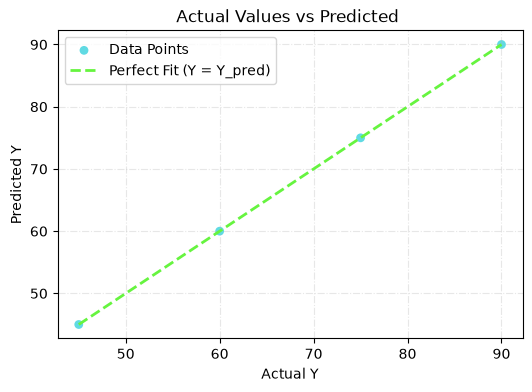

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6,4))
plt.scatter(y, y_pred, color="#38d1dc", edgecolor="none", s=40, label="Data Points", alpha=0.8)
min_val = min(float(np.min(y)), float(np.min(y_pred)))
max_val = max(float(np.max(y)), float(np.max(y_pred)))
plt.plot([min_val, max_val], [min_val, max_val], color="#66f43f", linestyle="--", linewidth=2, label="Perfect Fit (Y = Y_pred)")
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.title("Actual Values vs Predicted ")
plt.legend()
plt.grid(True, linestyle="-.", alpha=0.3)

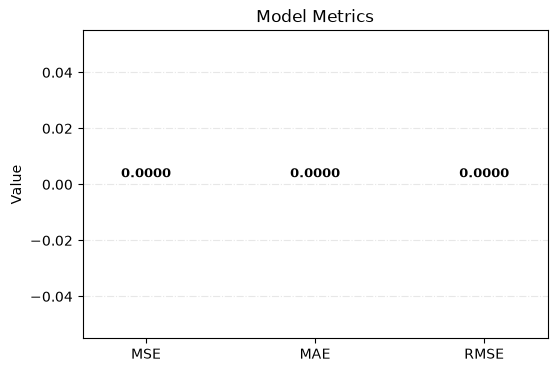

In [22]:
plt.figure(figsize=(6,4))
metrics_names = ["MSE", "MAE", "RMSE", "R2"]
metrics_vals = [mse, mae, rmse, r2]
colors = ["#a855f7", "#08d6d4", "#f43f5e", "#10b981"]
bars = plt.bar(metrics_names, metrics_vals, color=colors, alpha=0.85, width=0.5)
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.4f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.ylabel("Value")
plt.title("Model Metrics")
plt.grid(True, linestyle="-.", alpha=0.3, axis="y")

In [23]:
mae

0.0